# RS2 — LightGCN (Light Graph Convolutional Network)
**Advanced Recommender System extending RS1 via graph based embedding propagation.**

> ⚠️ Run `00_Data_Preparation.ipynb` AND `RS1_BPR_MF.ipynb` first before executing this notebook.

In [3]:
from google.colab import drive
drive.mount('/content/drive')

import os
BASE       = '/content/drive/MyDrive/Recommendation System'
PROC       = f'{BASE}/data/processed'
MODELS_DIR = f'{BASE}/models'
OUT_DIR    = f'{BASE}/outputs'
print('✅ Drive mounted.')

Mounted at /content/drive
✅ Drive mounted.


## Install PyTorch Geometric & Dependencies

In [4]:
# Install PyTorch Geometric (must match your Colab PyTorch/CUDA version)
import torch
print(f'PyTorch version: {torch.__version__}')

!pip install -q torch-geometric
!pip install -q torch-scatter torch-sparse -f https://data.pyg.org/whl/torch-$(python -c "import torch; print(torch.__version__)").html 2>/dev/null || echo 'sparse/scatter optional'
!pip install -q pandas numpy matplotlib tqdm

import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import pickle, json, time
import matplotlib.pyplot as plt
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

RANDOM_SEED = 42
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ Using device: {DEVICE}')

PyTorch version: 2.10.0+cu128
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 25.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.0/108.0 kB 4.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 210.0/210.0 kB 11.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
✅ Using device: cuda


## Load Preprocessed Data

In [5]:
train_df  = pd.read_csv(f'{PROC}/train.csv')
test_df   = pd.read_csv(f'{PROC}/test.csv')
movies_df = pd.read_csv(f'{PROC}/movies.csv')

with open(f'{PROC}/dataset_info.json') as f:
    info = json.load(f)
with open(f'{PROC}/train_user_items.pkl', 'rb') as f:
    train_user_items = pickle.load(f)
with open(f'{PROC}/item_popularity.pkl', 'rb') as f:
    item_popularity = pickle.load(f)

# ✅ Use max index + 1 (same fix as RS1)
NUM_USERS = int(train_df['user_idx'].max()) + 1
NUM_ITEMS = int(train_df['item_idx'].max()) + 1

idx_to_title = dict(zip(movies_df['item_idx'], movies_df['title']))

print(f'Users : {NUM_USERS:,}')
print(f'Items : {NUM_ITEMS:,}')
print(f'Train : {len(train_df):,}  |  Test: {len(test_df):,}')
print(f'Max user_idx : {train_df["user_idx"].max()}')
print(f'Max item_idx : {train_df["item_idx"].max()}')
print('✅ Data loaded.')

Users : 6,018
Items : 3,390
Train : 143,978  |  Test: 5,934
Max user_idx : 6017
Max item_idx : 3389
✅ Data loaded.


## Build Bipartite Graph

In [6]:
# LightGCN Graph Construction
# I build a bipartite graph where:
#   - User nodes: indices 0 ... NUM_USERS-1
#   - Item nodes: indices NUM_USERS ... NUM_USERS+NUM_ITEMS-1  (offset by NUM_USERS)


user_ids_train = train_df['user_idx'].values
item_ids_train = train_df['item_idx'].values + NUM_USERS  # offset items

# Build edge_index: shape (2, 2*num_edges) for undirected graph
src = np.concatenate([user_ids_train, item_ids_train])  # from
dst = np.concatenate([item_ids_train, user_ids_train])  # to
edge_index = torch.tensor([src, dst], dtype=torch.long).to(DEVICE)

total_nodes = NUM_USERS + NUM_ITEMS

# ✅ Verify no index exceeds total nodes
assert edge_index.max().item() < total_nodes, \
    f'❌ Edge index {edge_index.max().item()} >= total nodes {total_nodes}'

print(f'Total nodes : {total_nodes:,}  (users: {NUM_USERS:,} + items: {NUM_ITEMS:,})')
print(f'Total edges : {edge_index.shape[1]:,}')
print(f'Max edge index : {edge_index.max().item()}  (must be < {total_nodes})')
print('✅ Graph built safely.')

Total nodes : 9,408  (users: 6,018 + items: 3,390)
Total edges : 287,956
Max edge index : 9407  (must be < 9408)
✅ Graph built safely.


## LightGCN Model Definition

In [7]:
from torch_geometric.nn import LGConv

class LightGCN(nn.Module):
    def __init__(self, num_users, num_items, embedding_dim=64, num_layers=3, reg_lambda=1e-4):
        super(LightGCN, self).__init__()
        self.num_users    = num_users
        self.num_items    = num_items
        self.embedding_dim = embedding_dim
        self.num_layers   = num_layers
        self.reg_lambda   = reg_lambda

        # One shared embedding table for ALL nodes (users + items)
        total_nodes = num_users + num_items
        self.embedding = nn.Embedding(total_nodes, embedding_dim)
        nn.init.xavier_uniform_(self.embedding.weight)

        # LGConv layers — each implements the symmetric normalised aggregation
        self.convs = nn.ModuleList([LGConv() for _ in range(num_layers)])

    def propagate(self, edge_index):
        """
        Run L layers of graph convolution and return the
        mean-pooled embedding across all layers (including layer 0).
        """
        x = self.embedding.weight  # initial embeddings (num_nodes, dim)
        all_layer_embs = [x]       # collect embeddings from each layer

        for conv in self.convs:
            x = conv(x, edge_index)
            all_layer_embs.append(x)

        # Final embedding = mean across all layers (0 through L)
        final_emb = torch.stack(all_layer_embs, dim=0).mean(dim=0)
        return final_emb

    def forward(self, edge_index, users, pos_items, neg_items):
        """
        Compute BPR loss using graph-propagated embeddings.
        """
        final_emb = self.propagate(edge_index)

        # Split final embeddings back into user and item parts
        user_embs = final_emb[:self.num_users]            # (num_users, dim)
        item_embs = final_emb[self.num_users:]            # (num_items, dim)

        u  = user_embs[users]      # (batch, dim)
        pi = item_embs[pos_items]  # (batch, dim)
        ni = item_embs[neg_items]  # (batch, dim)

        pos_score = (u * pi).sum(dim=1)
        neg_score = (u * ni).sum(dim=1)

        bpr_loss = -torch.log(torch.sigmoid(pos_score - neg_score) + 1e-10).mean()

        # Regularise only the initial embeddings (not propagated ones)
        init_u  = self.embedding.weight[users]
        init_pi = self.embedding.weight[self.num_users + pos_items]
        init_ni = self.embedding.weight[self.num_users + neg_items]
        reg_loss = self.reg_lambda * (
            init_u.norm(2).pow(2) + init_pi.norm(2).pow(2) + init_ni.norm(2).pow(2)
        ) / users.shape[0]

        return bpr_loss + reg_loss

    def get_scores(self, edge_index, user_idx):
        """Return scores for all items for a single user."""
        final_emb = self.propagate(edge_index)
        user_emb  = final_emb[user_idx]       # (dim,)
        item_embs = final_emb[self.num_users:] # (num_items, dim)
        scores = torch.matmul(item_embs, user_emb)
        return scores.detach().cpu().numpy()


# Instantiate model
EMBEDDING_DIM = 64
NUM_LAYERS    = 3

model_rs2 = LightGCN(
    num_users=NUM_USERS,
    num_items=NUM_ITEMS,
    embedding_dim=EMBEDDING_DIM,
    num_layers=NUM_LAYERS
).to(DEVICE)

print(model_rs2)
total_params = sum(p.numel() for p in model_rs2.parameters())
print(f'\nTotal parameters: {total_params:,}')
print(f'Graph layers: {NUM_LAYERS}  |  Embedding dim: {EMBEDDING_DIM}')

LightGCN(
  (embedding): Embedding(9408, 64)
  (convs): ModuleList(
    (0-2): 3 x LGConv()
  )
)

Total parameters: 602,112
Graph layers: 3  |  Embedding dim: 64


##  BPR Dataset (same as RS1 for fair comparison)

In [8]:
from torch.utils.data import Dataset, DataLoader

class BPRDataset(Dataset):
    """Identical dataset to RS1 — same negative sampling strategy."""
    def __init__(self, train_df, train_user_items, num_items):
        self.interactions   = list(zip(train_df['user_idx'], train_df['item_idx']))
        self.train_user_items = train_user_items
        self.num_items       = num_items

    def __len__(self):
        return len(self.interactions)

    def __getitem__(self, idx):
        user, pos_item = self.interactions[idx]
        neg_item = np.random.randint(0, self.num_items)
        while neg_item in self.train_user_items.get(user, set()):
            neg_item = np.random.randint(0, self.num_items)
        return (
            torch.tensor(user,     dtype=torch.long),
            torch.tensor(pos_item, dtype=torch.long),
            torch.tensor(neg_item, dtype=torch.long)
        )

dataset = BPRDataset(train_df, train_user_items, NUM_ITEMS)
loader  = DataLoader(dataset, batch_size=2048, shuffle=True, num_workers=2)
print(f'✅ BPR Dataset ready. Batches per epoch: {len(loader):,}')

✅ BPR Dataset ready. Batches per epoch: 71


## Training Loop

In [9]:
EPOCHS    = 80
LR        = 0.001
optimizer = optim.Adam(model_rs2.parameters(), lr=LR)

model_rs2 = LightGCN(
    num_users=NUM_USERS,
    num_items=NUM_ITEMS,
    embedding_dim=EMBEDDING_DIM,
    num_layers=NUM_LAYERS
).to(DEVICE)
optimizer = optim.Adam(model_rs2.parameters(), lr=LR)

train_losses = []
start_time   = time.time()

print(f'Training RS2 (LightGCN) for {EPOCHS} epochs...')
print(f'Graph layers: {NUM_LAYERS}  |  Embedding dim: {EMBEDDING_DIM}  |  LR: {LR}')
print('-' * 60)

for epoch in range(1, EPOCHS + 1):
    model_rs2.train()
    epoch_loss = 0.0

    for batch_users, batch_pos, batch_neg in loader:
        batch_users = batch_users.to(DEVICE)
        batch_pos   = batch_pos.to(DEVICE)
        batch_neg   = batch_neg.to(DEVICE)

        optimizer.zero_grad()
        loss = model_rs2(edge_index, batch_users, batch_pos, batch_neg)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(loader)
    train_losses.append(avg_loss)

    if epoch % 10 == 0 or epoch == 1:
        elapsed = time.time() - start_time
        print(f'Epoch {epoch:3d}/{EPOCHS} | Loss: {avg_loss:.5f} | Time: {elapsed:.1f}s')

print('-' * 60)
print(f'✅ Training complete in {(time.time()-start_time)/60:.1f} minutes.')

torch.save(model_rs2.state_dict(), f'{MODELS_DIR}/rs2_lightgcn.pth')
print('✅ Model saved.')

Training RS2 (LightGCN) for 80 epochs...
Graph layers: 3  |  Embedding dim: 64  |  LR: 0.001
------------------------------------------------------------
Epoch   1/80 | Loss: 0.67302 | Time: 5.9s
Epoch  10/80 | Loss: 0.42522 | Time: 48.2s
Epoch  20/80 | Loss: 0.41223 | Time: 96.0s
Epoch  30/80 | Loss: 0.40010 | Time: 142.2s
Epoch  40/80 | Loss: 0.37700 | Time: 188.1s
Epoch  50/80 | Loss: 0.35169 | Time: 234.9s
Epoch  60/80 | Loss: 0.33498 | Time: 281.8s
Epoch  70/80 | Loss: 0.31756 | Time: 328.6s
Epoch  80/80 | Loss: 0.30296 | Time: 374.7s
------------------------------------------------------------
✅ Training complete in 6.2 minutes.
✅ Model saved.


## Plot Training Loss (RS1 vs RS2 Comparison)

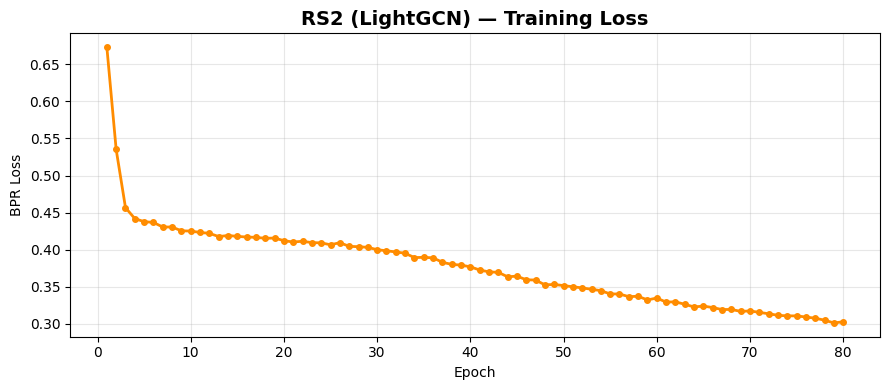

✅ Training loss plot saved.


In [10]:
# Load RS1 losses if available
try:
    rs1_losses_path = f'{OUT_DIR}/rs1_training_loss_data.npy'
    rs1_train_losses = np.load(rs1_losses_path) if os.path.exists(rs1_losses_path) else None
except:
    rs1_train_losses = None

plt.figure(figsize=(9, 4))
plt.plot(range(1, EPOCHS+1), train_losses, marker='o', markersize=4,
         color='darkorange', linewidth=2, label='RS2 LightGCN')
if rs1_train_losses is not None:
    plt.plot(range(1, len(rs1_train_losses)+1), rs1_train_losses, marker='s', markersize=4,
             color='steelblue', linewidth=2, linestyle='--', label='RS1 BPR-MF')
    plt.legend()

plt.title('RS2 (LightGCN) — Training Loss', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('BPR Loss')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/rs2_training_loss.png', dpi=150)
plt.show()
print('✅ Training loss plot saved.')

## Recommendation Function

In [11]:
def recommend_rs2(model, edge_index, user_idx, train_user_items, k=10):
    """
    Generate Top-K recommendations using LightGCN propagated embeddings.

    Steps:
    1. Run full graph propagation to get final embeddings for all nodes.
    2. Extract user embedding and all item embeddings.
    3. Compute dot product scores.
    4. Mask seen items, return Top-K.
    """
    model.eval()
    with torch.no_grad():
        scores = model.get_scores(edge_index, user_idx)  # (num_items,)

    seen = train_user_items.get(user_idx, set())
    for item in seen:
        scores[item] = -np.inf

    top_k = np.argsort(scores)[::-1][:k]
    return top_k.tolist()


# Quick test
sample_user = list(train_user_items.keys())[0]
recs = recommend_rs2(model_rs2, edge_index, sample_user, train_user_items, k=10)
print(f'Top-10 recommendations for user {sample_user} (LightGCN):')
for rank, item_idx in enumerate(recs, 1):
    title = idx_to_title.get(item_idx, f'Movie_{item_idx}')
    print(f'  {rank:2d}. {title}')

Top-10 recommendations for user 0 (LightGCN):
   1. Star Wars: Episode IV - A New Hope (1977)
   2. Jurassic Park (1993)
   3. Men in Black (1997)
   4. Star Wars: Episode I - The Phantom Menace (1999)
   5. Braveheart (1995)
   6. Saving Private Ryan (1998)
   7. Raiders of the Lost Ark (1981)
   8. American Beauty (1999)
   9. Fugitive, The (1993)
  10. Back to the Future (1985)


## Evaluation Metrics

In [12]:
def ndcg_at_k(recommended_list, test_item, k=10):
    """NDCG@K — ranking accuracy metric."""
    if test_item in recommended_list[:k]:
        rank = recommended_list[:k].index(test_item) + 1
        return 1.0 / np.log2(rank + 1)
    return 0.0

def novelty_at_k(recommended_list, item_popularity, k=10):
    """Novelty@K — beyond-accuracy metric (higher = more novel)."""
    top_k = recommended_list[:k]
    scores = [-np.log2(item_popularity.get(i, 1e-10) + 1e-10) for i in top_k]
    return np.mean(scores)

print('✅ Metric functions defined (identical to RS1).')

✅ Metric functions defined (identical to RS1).


## Run Full Evaluation on RS2

In [13]:
K = 10
ndcg_scores    = []
novelty_scores = []

model_rs2.eval()
test_users = test_df['user_idx'].tolist()
test_items = test_df['item_idx'].tolist()

print(f'Evaluating RS2 on {len(test_users):,} users...')

for user_idx, test_item in tqdm(zip(test_users, test_items), total=len(test_users)):
    recs = recommend_rs2(model_rs2, edge_index, user_idx, train_user_items, k=K)
    ndcg_scores.append(ndcg_at_k(recs, test_item, k=K))
    novelty_scores.append(novelty_at_k(recs, item_popularity, k=K))

rs2_ndcg    = np.mean(ndcg_scores)
rs2_novelty = np.mean(novelty_scores)

print('\n' + '='*40)
print('RS2 (LightGCN) Evaluation Results')
print('='*40)
print(f'  NDCG@{K}:    {rs2_ndcg:.5f}')
print(f'  Novelty@{K}: {rs2_novelty:.4f}')
print('='*40)

rs2_results = {
    'model': 'RS2_LightGCN',
    f'ndcg@{K}': round(rs2_ndcg, 6),
    f'novelty@{K}': round(rs2_novelty, 6),
    'num_eval_users': len(test_users)
}
with open(f'{OUT_DIR}/rs2_results.json', 'w') as f:
    json.dump(rs2_results, f, indent=2)
print('\n✅ Results saved.')

Evaluating RS2 on 5,934 users...


100%|██████████| 5934/5934 [00:37<00:00, 159.80it/s]


RS2 (LightGCN) Evaluation Results
  NDCG@10:    0.01533
  Novelty@10: 4.3832

✅ Results saved.


## Display Top-10 Recommendations for 6 Users (Same Users as RS1)

In [14]:
demo_users = list(train_user_items.keys())[:6]  # Same 6 users as RS1

print('RS2 (LightGCN) — Top-10 Recommendations for 6 Users')
print('='*65)

rs2_demo_recs = {}

for user_idx in demo_users:
    recs = recommend_rs2(model_rs2, edge_index, user_idx, train_user_items, k=10)
    rs2_demo_recs[user_idx] = recs
    print(f'\nUser {user_idx} | Seen {len(train_user_items[user_idx])} movies in training')
    print('-'*50)
    for rank, item_idx in enumerate(recs, 1):
        title = idx_to_title.get(item_idx, f'Movie_{item_idx}')
        print(f'  {rank:2d}. [{item_idx:4d}] {title}')

with open(f'{OUT_DIR}/rs2_demo_recs.json', 'w') as f:
    json.dump({str(k): v for k,v in rs2_demo_recs.items()}, f, indent=2)
print('\n✅ Demo recommendations saved.')

RS2 (LightGCN) — Top-10 Recommendations for 6 Users

User 0 | Seen 47 movies in training
--------------------------------------------------
   1. [  27] Star Wars: Episode IV - A New Hope (1977)
   2. [  75] Jurassic Park (1993)
   3. [  15] Men in Black (1997)
   4. [ 109] Star Wars: Episode I - The Phantom Menace (1999)
   5. [ 190] Braveheart (1995)
   6. [ 291] Saving Private Ryan (1998)
   7. [ 440] Raiders of the Lost Ark (1981)
   8. [ 465] American Beauty (1999)
   9. [ 491] Fugitive, The (1993)
  10. [  88] Back to the Future (1985)

User 1 | Seen 7 movies in training
--------------------------------------------------
   1. [ 465] American Beauty (1999)
   2. [ 511] Fargo (1996)
   3. [1063] Being John Malkovich (1999)
   4. [ 540] Shakespeare in Love (1998)
   5. [  81] Shawshank Redemption, The (1994)
   6. [ 339] Schindler's List (1993)
   7. [  33] Good Will Hunting (1997)
   8. [ 138] Pulp Fiction (1994)
   9. [ 293] Silence of the Lambs, The (1991)
  10. [ 989] L.A. Conf

##  Final RS1 vs RS2 Comparison (Load RS1 results & Compare)

In [17]:
# Load RS1 results
with open(f'{OUT_DIR}/rs1_results.json') as f:
    rs1_results = json.load(f)

rs1_ndcg    = rs1_results[f'ndcg@{K}']
rs1_novelty = rs1_results[f'novelty@{K}']

# Compute improvement
ndcg_improvement    = ((rs2_ndcg    - rs1_ndcg)    / rs1_ndcg)    * 100
novelty_improvement = ((rs2_novelty - rs1_novelty) / rs1_novelty) * 100

# Sign symbols
ndcg_sign    = "+" if ndcg_improvement    >= 0 else "-"
novelty_sign = "+" if novelty_improvement >= 0 else "-"

print('\n' + '='*55)
print(f'{"Metric":<20} {"RS1 (BPR-MF)":>15} {"RS2 (LightGCN)":>15}')
print('='*55)
print(f'{"NDCG@10":<20} {rs1_ndcg:>15.5f} {rs2_ndcg:>15.5f}')
print(f'{"Novelty@10":<20} {rs1_novelty:>15.4f} {rs2_novelty:>15.4f}')
print('='*55)
print(f'{"NDCG Change":<20} {ndcg_sign}{abs(ndcg_improvement):>14.2f}%')
print(f'{"Novelty Change":<20} {novelty_sign}{abs(novelty_improvement):>14.2f}%')
print('='*55)


Metric                  RS1 (BPR-MF)  RS2 (LightGCN)
NDCG@10                      0.01491         0.01533
Novelty@10                    4.4236          4.3832
NDCG Change          +          2.85%
Novelty Change       -          0.91%


## Comparison Charts

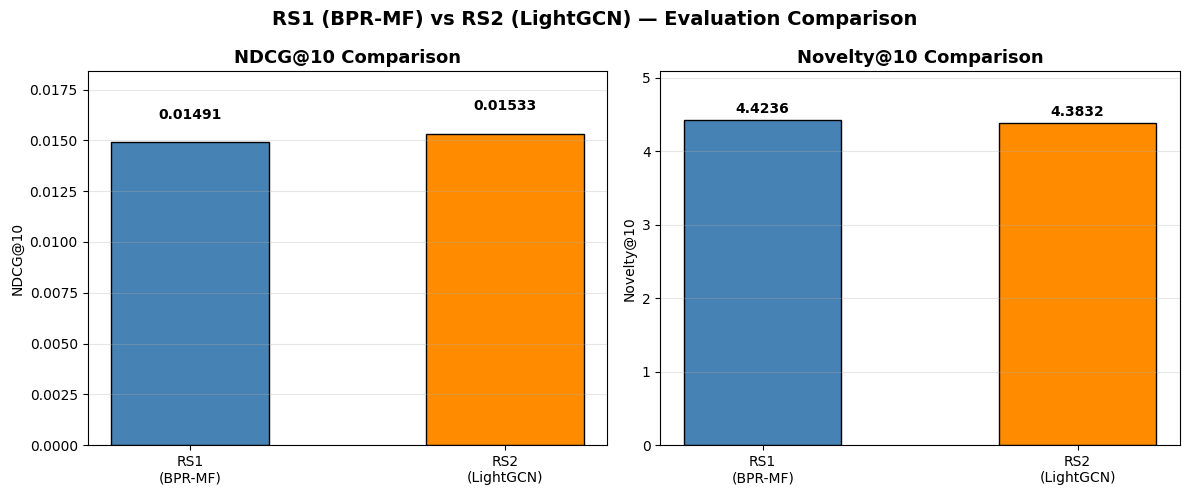

✅ Comparison chart saved.


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

models  = ['RS1\n(BPR-MF)', 'RS2\n(LightGCN)']
colors  = ['steelblue', 'darkorange']

# NDCG bar chart
ndcg_vals = [rs1_ndcg, rs2_ndcg]
bars = axes[0].bar(models, ndcg_vals, color=colors, edgecolor='black', width=0.5)
for bar, val in zip(bars, ndcg_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                 f'{val:.5f}', ha='center', va='bottom', fontweight='bold')
axes[0].set_title(f'NDCG@{K} Comparison', fontsize=13, fontweight='bold')
axes[0].set_ylabel(f'NDCG@{K}')
axes[0].set_ylim(0, max(ndcg_vals) * 1.2)
axes[0].grid(axis='y', alpha=0.3)

# Novelty bar chart
nov_vals = [rs1_novelty, rs2_novelty]
bars2 = axes[1].bar(models, nov_vals, color=colors, edgecolor='black', width=0.5)
for bar, val in zip(bars2, nov_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                 f'{val:.4f}', ha='center', va='bottom', fontweight='bold')
axes[1].set_title(f'Novelty@{K} Comparison', fontsize=13, fontweight='bold')
axes[1].set_ylabel(f'Novelty@{K}')
axes[1].set_ylim(0, max(nov_vals) * 1.15)
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('RS1 (BPR-MF) vs RS2 (LightGCN) — Evaluation Comparison',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/rs1_vs_rs2_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Comparison chart saved.')

## Save Combined Results Summary

In [19]:
import csv

summary = [
    {'model': 'RS1_BPR_MF',   f'ndcg@{K}': rs1_ndcg,  f'novelty@{K}': rs1_novelty},
    {'model': 'RS2_LightGCN', f'ndcg@{K}': rs2_ndcg,  f'novelty@{K}': rs2_novelty},
]

summary_path = f'{OUT_DIR}/results_summary.csv'
with open(summary_path, 'w', newline='') as f:
    writer = csv.DictWriter(f, fieldnames=['model', f'ndcg@{K}', f'novelty@{K}'])
    writer.writeheader()
    writer.writerows(summary)

print(f'✅ Results summary saved to {summary_path}')
print('\nAll outputs saved to:', OUT_DIR)

✅ Results summary saved to /content/drive/MyDrive/Recommendation System/outputs/results_summary.csv

All outputs saved to: /content/drive/MyDrive/Recommendation System/outputs
